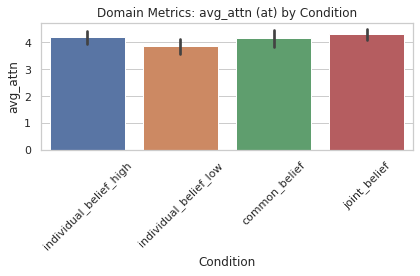

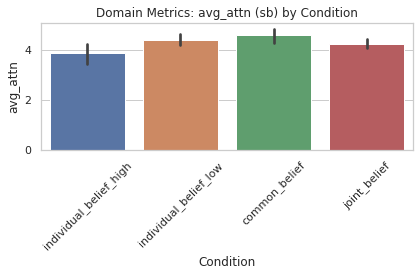

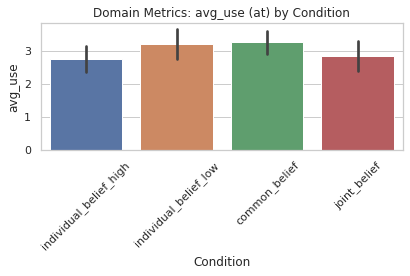

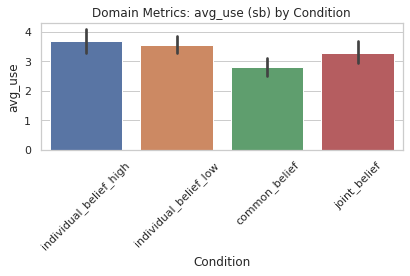

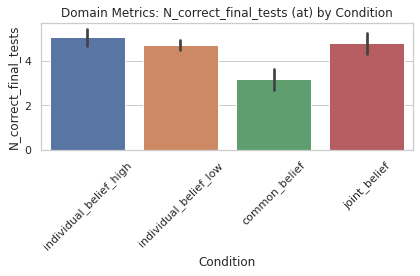

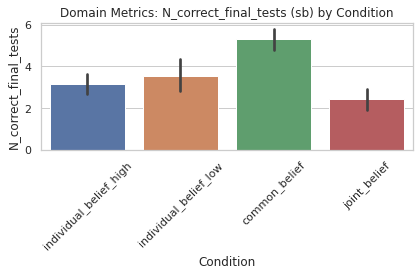

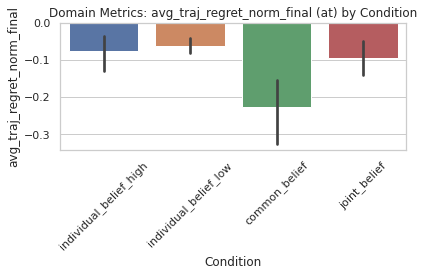

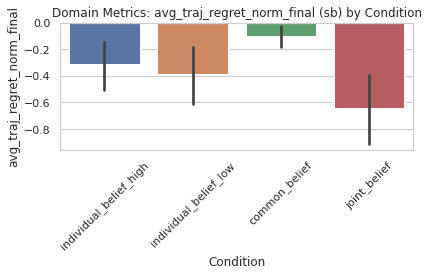

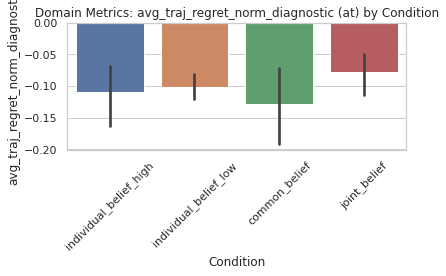

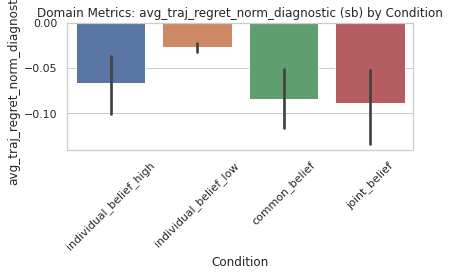

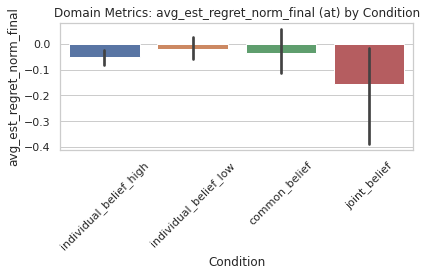

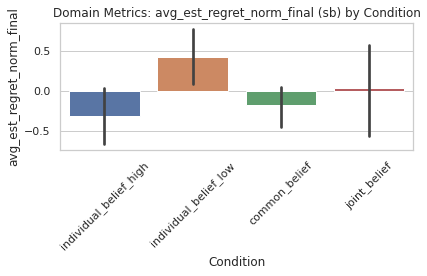

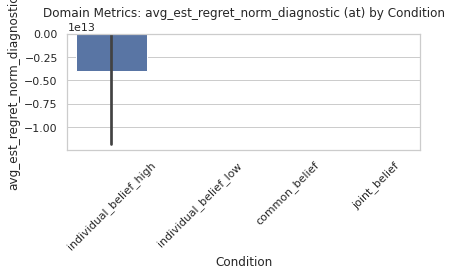

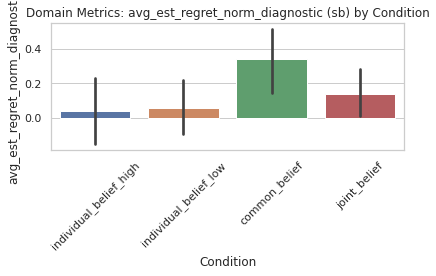

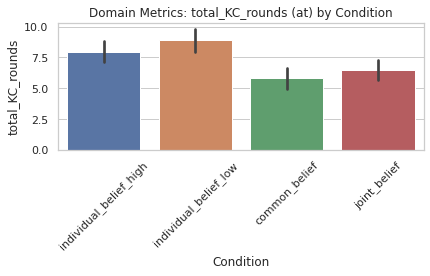

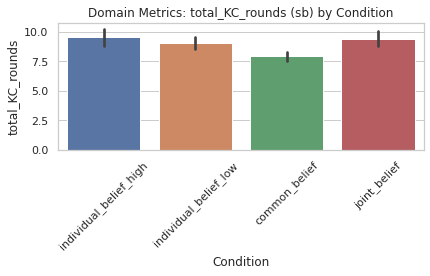

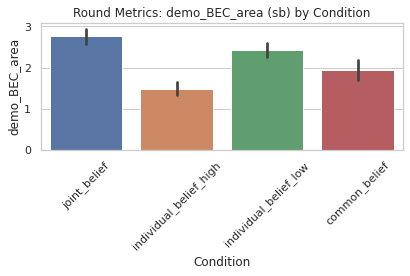

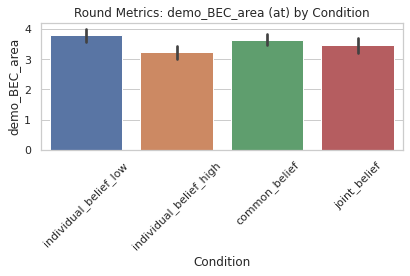

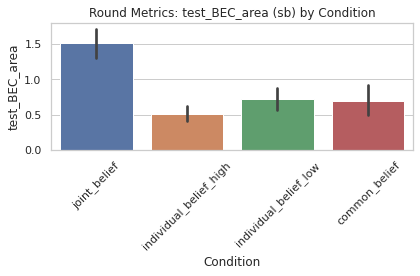

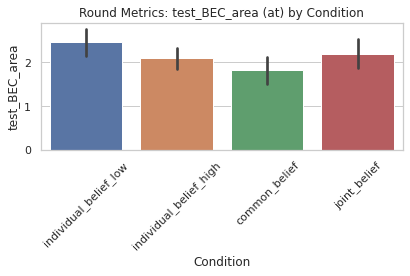

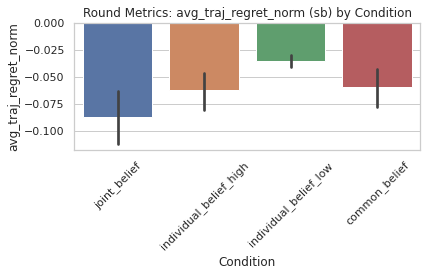

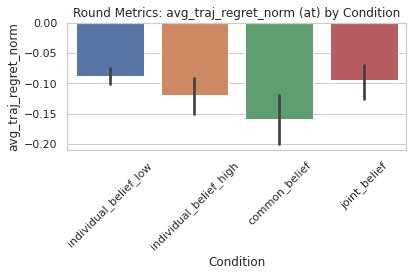

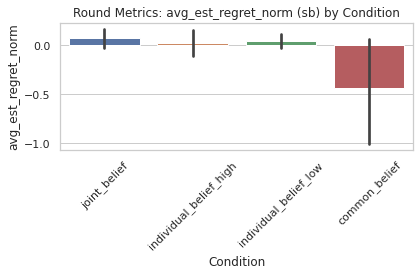

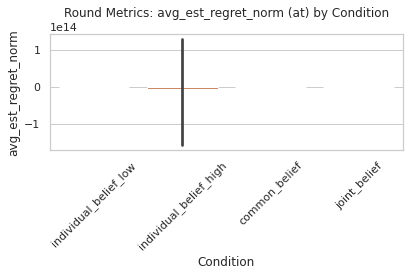

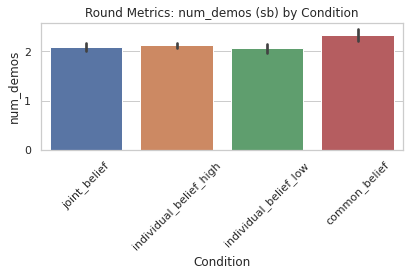

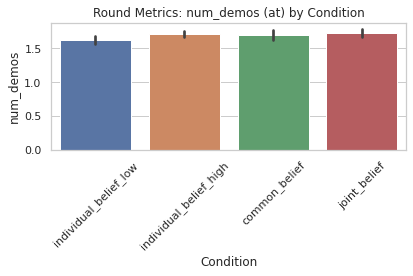

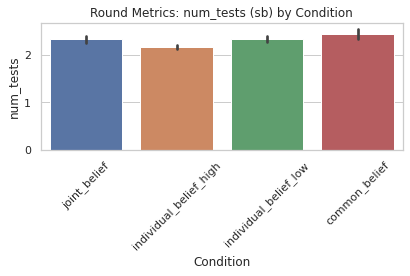

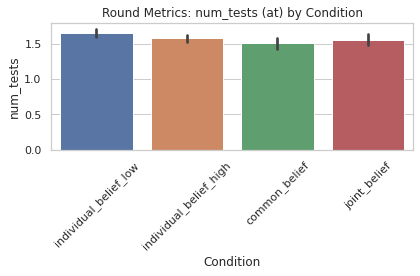

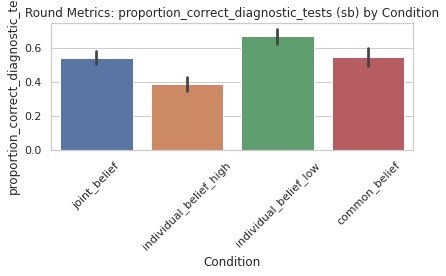

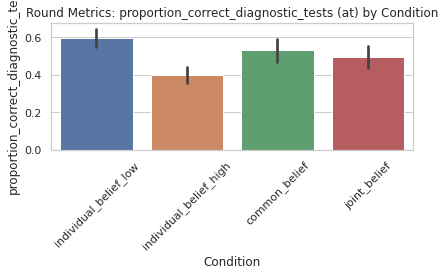

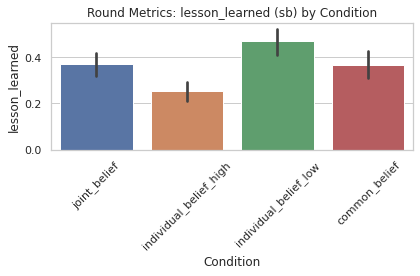

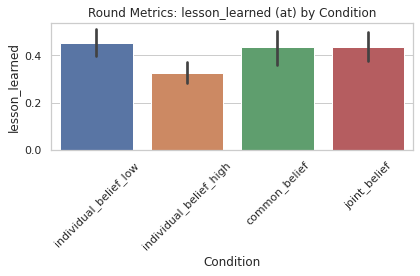

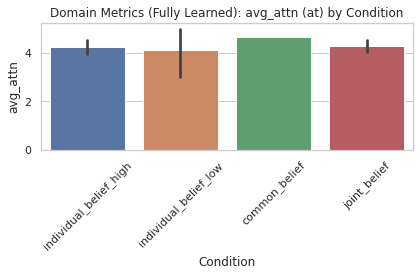

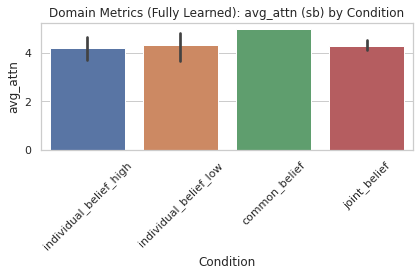

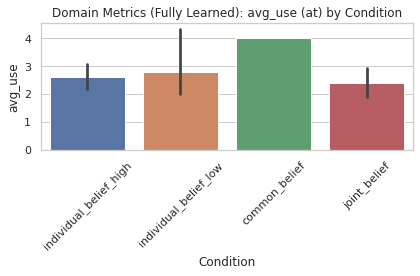

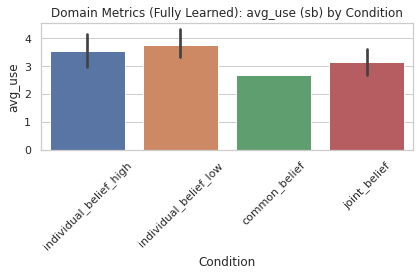

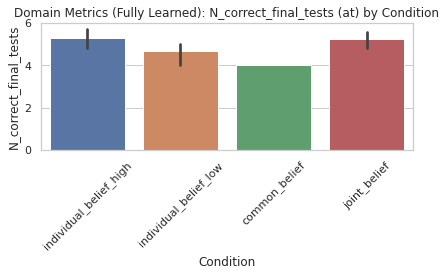

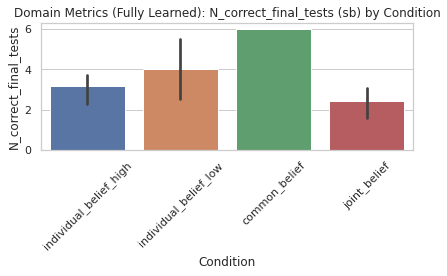

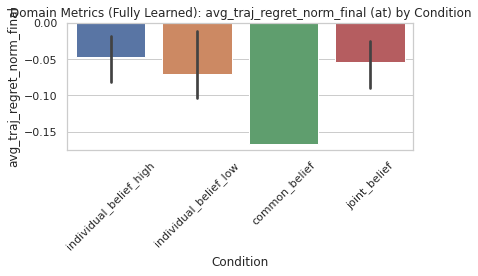

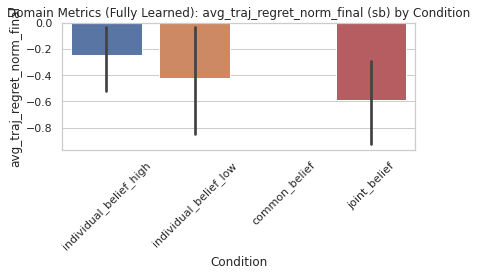

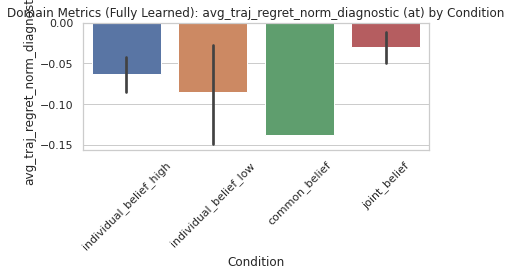

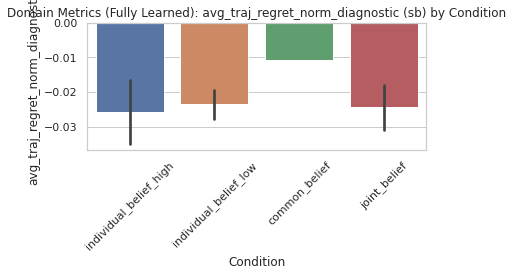

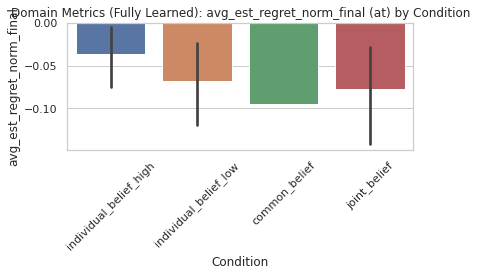

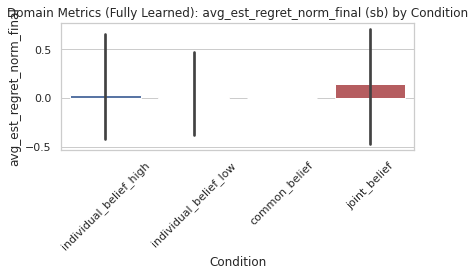

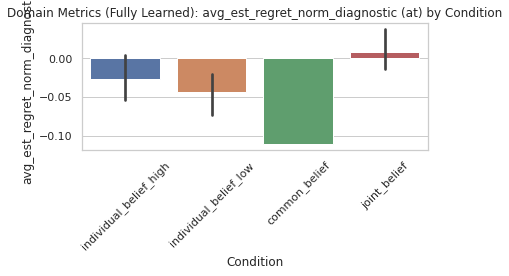

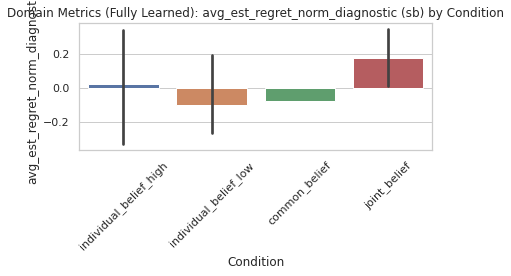

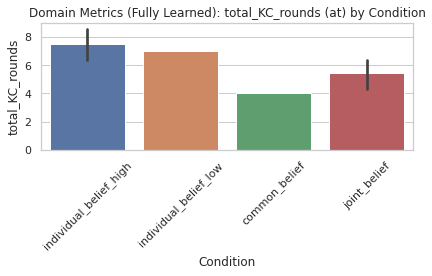

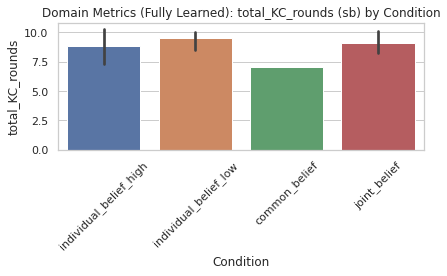

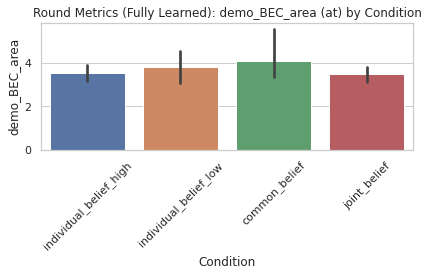

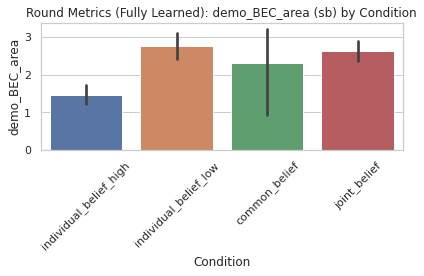

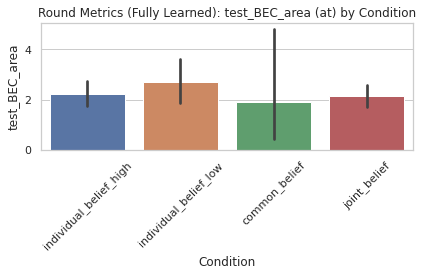

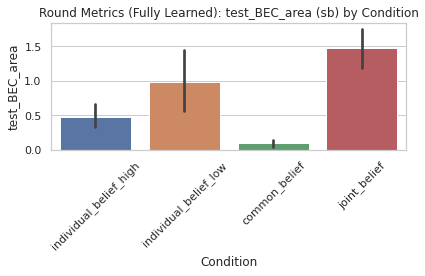

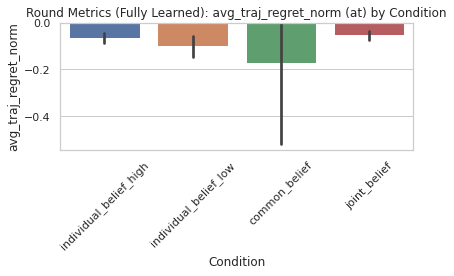

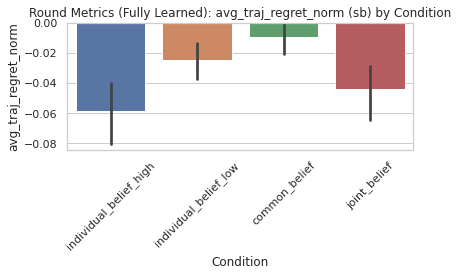

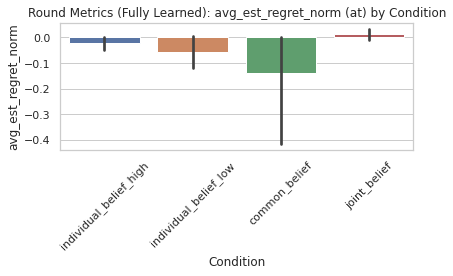

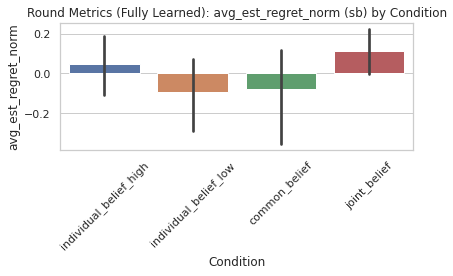

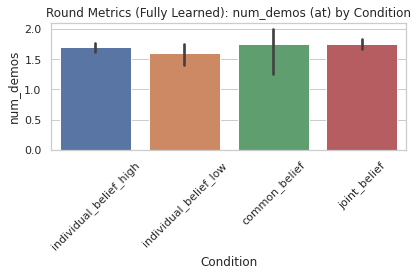

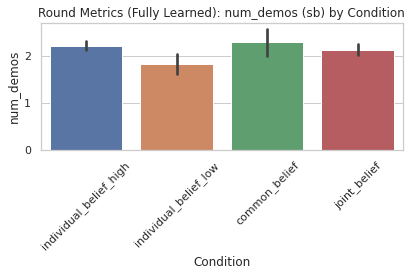

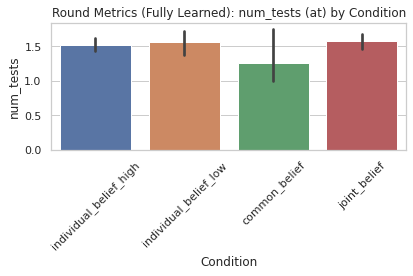

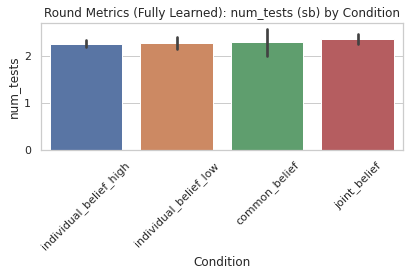

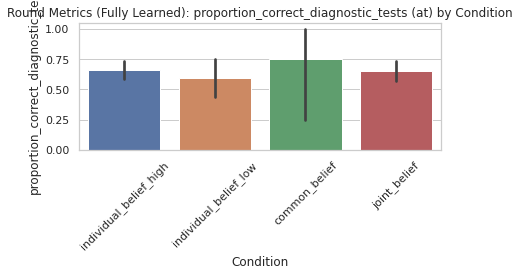

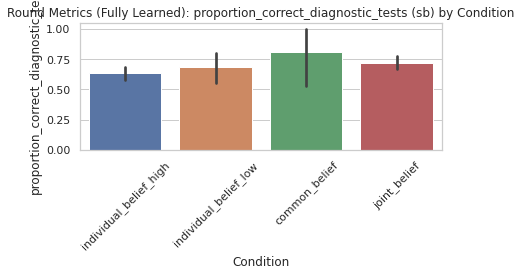

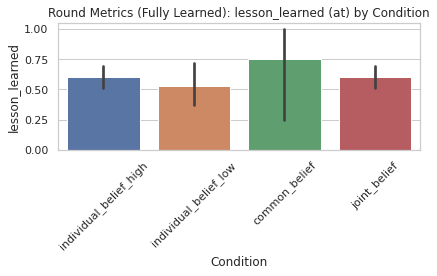

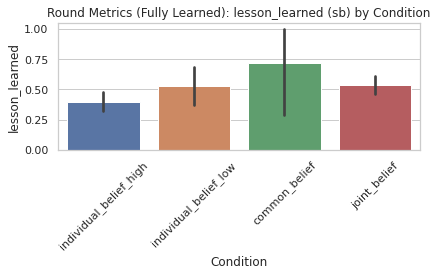


--- Variable: overall_domain_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


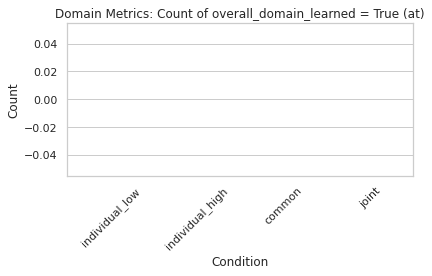

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


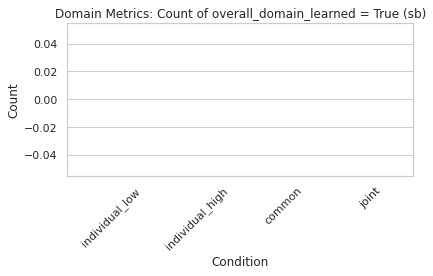


--- Variable: KC_0_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


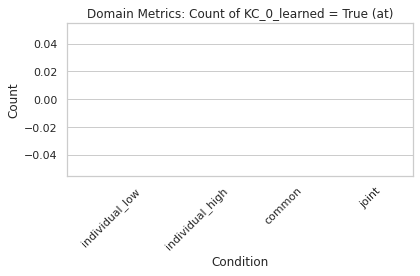

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


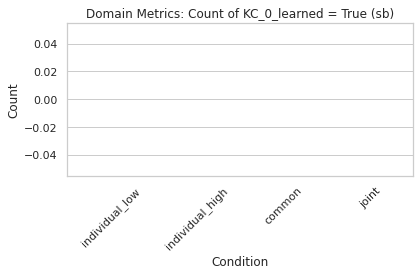


--- Variable: KC_1_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


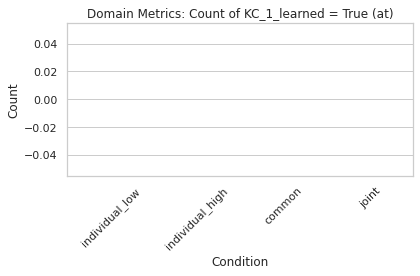

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


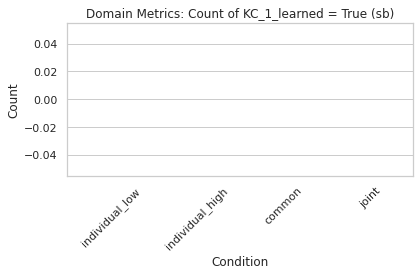


--- Variable: KC_2_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


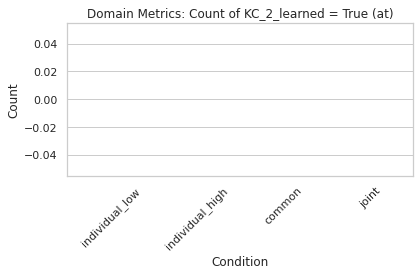

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


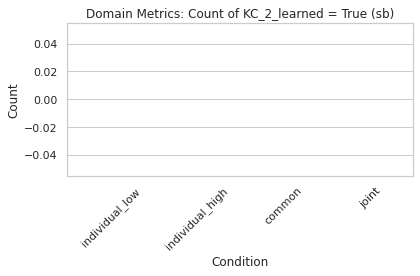


--- Variable: overall_domain_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


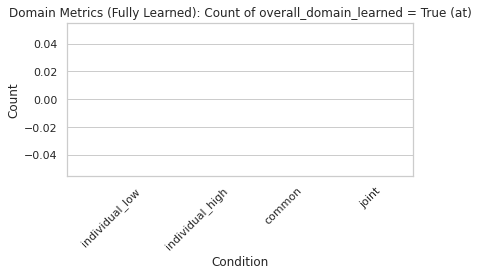

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


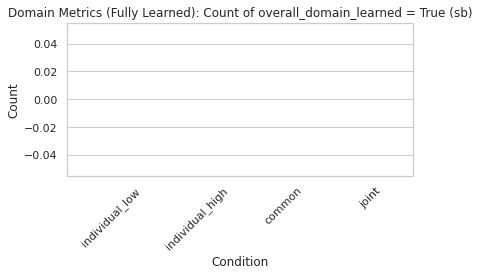


--- Variable: KC_0_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


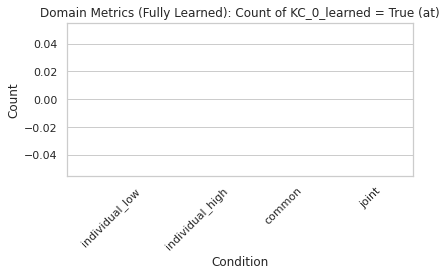

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


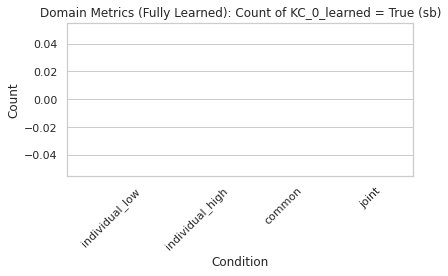


--- Variable: KC_1_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


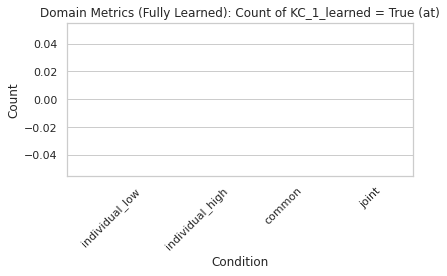

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


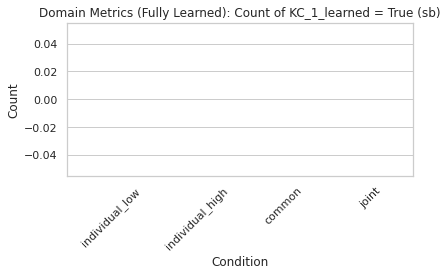


--- Variable: KC_2_learned ---
  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


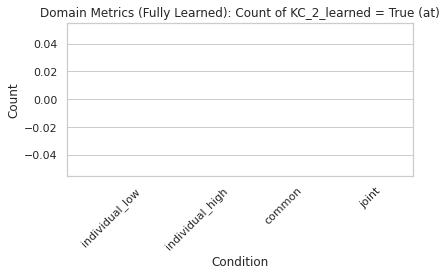

  experimental_condition  count
0         individual_low    NaN
1        individual_high    NaN
2                 common    NaN
3                  joint    NaN


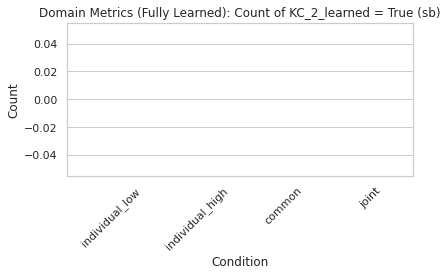

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

# Load data
# domain_df = pd.read_excel("../results/domain_df_w_metrics.xlsx")
domain_df = pd.read_excel("../results/expanded_metrics_data.xlsx", sheet_name="domain_df")

domain_df_learned = domain_df[domain_df['overall_domain_learned'] == 1]
users_learned = domain_df_learned['user_id'].unique()


string_cols = ['domain', 'domain_name', 'experimental_condition', 'domain_order', 'user_id', 'group_id']

# Ensure string columns are string
for col in string_cols:
    if col in domain_df.columns:
        domain_df[col] = domain_df[col].astype(str)

# round_df = pd.read_excel("../results/round_df_w_metrics.xlsx")
round_df = pd.read_excel("../results/expanded_metrics_data.xlsx", sheet_name="round_df")
round_df_learned = round_df[round_df['user_id'].isin(users_learned)]


# string_cols = ['domain', 'domain_name', 'experimental_condition', 'domain_order', 'user_id', 'group_id']

# Order settings
condition_order = ['individual_low', 'individual_high', 'common', 'joint']
domain_order = ['augmented_taxi2', 'skateboard2']


# Dependent variables
domain_vars = ['avg_attn', 'avg_use', 'N_correct_final_tests',
               'avg_traj_regret_norm_final', 'avg_traj_regret_norm_diagnostic',
               'avg_est_regret_norm_final', 'avg_est_regret_norm_diagnostic', 'total_KC_rounds']

round_vars = ['demo_BEC_area', 'test_BEC_area', 'avg_traj_regret_norm',
              'avg_est_regret_norm', 'num_demos', 'num_tests',
              'proportion_correct_diagnostic_tests', 'lesson_learned']

domain_vars_boolean = ['overall_domain_learned', 'KC_0_learned', 'KC_1_learned', 'KC_2_learned']

traj_regret_vars = ['avg_traj_regret_norm_final', 'avg_traj_regret_norm_diagnostic', 'avg_traj_regret_norm']
est_regret_vars = ['avg_est_regret_norm_final', 'avg_est_regret_norm_diagnostic', 'avg_est_regret_norm']

# Binning for regret variables
combined_traj_regret = pd.concat([
    domain_df['avg_traj_regret_norm_final'],
    domain_df['avg_traj_regret_norm_diagnostic'],
    round_df['avg_traj_regret_norm']
])
combined_est_regret = pd.concat([
    domain_df['avg_est_regret_norm_final'],
    domain_df['avg_est_regret_norm_diagnostic'],
    round_df['avg_est_regret_norm']
])

traj_bins = np.array(np.histogram_bin_edges(combined_traj_regret.dropna(), bins=15))
est_bins = np.array(np.histogram_bin_edges(combined_est_regret.dropna(), bins=15))

# Scale factor
scale_factor = 240 / len(domain_df)

# Check discreteness
def is_discrete(series):
    return pd.api.types.is_integer_dtype(series) or series.nunique() < 4

# 1. Overall histograms
def plot_overall_histograms(df, variables, title_prefix):
    for var in variables:
        data = df[var].dropna()
        weights = np.ones_like(data) * scale_factor
        discrete = is_discrete(data)
        print(f"Variable: {var}, Discrete: {discrete}")

        bins = None
        if var in traj_regret_vars:
            bins = traj_bins
        elif var in est_regret_vars:
            bins = est_bins

        df_plot = pd.DataFrame({var: data, "weights": weights})

        plt.figure(figsize=(6, 4))
        if bins is not None:
            sns.histplot(
                data=df_plot,
                x=var,
                weights="weights",
                discrete=discrete,
                bins=bins,
                palette="muted"
            )
        else:
            sns.histplot(
            data=df_plot,
            x=var,
            weights="weights",
            discrete=discrete,
            palette="muted"
        )
        plt.title(f"{title_prefix}: {var}")
        plt.xlabel(var)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

# plot_overall_histograms(domain_df, domain_vars, "Domain Metrics")
# plot_overall_histograms(round_df, round_vars, "Round Metrics")


# 2. Histograms split by domain
def plot_histograms_by_domain(df, variables, title_prefix):
    df = df.copy()
    df['weights'] = scale_factor  # ensure scale_factor is defined externally

    domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'
    print(f"Plotting by domain column: {domain_col}, domains: {df[domain_col].unique()}")

    for var in variables:
        print(f"\n--- Variable: {var} ---")

        discrete = is_discrete(df[var])

        bins = None
        if var in traj_regret_vars:
            bins = traj_bins
        elif var in est_regret_vars:
            bins = est_bins

        g = sns.FacetGrid(df, col=domain_col, margin_titles=True,
                          height=4, aspect=1.2, sharey=False)

        plot_args = dict(x=var, weights='weights', discrete=discrete,
                         color=sns.color_palette("muted")[0], stat='count')

        if bins is not None:
            plot_args['bins'] = bins

        g.map_dataframe(sns.histplot, **plot_args)
        g.set_axis_labels(var, "Count")
        g.fig.subplots_adjust(top=0.85)
        g.fig.suptitle(f"{title_prefix}: {var}", fontsize=14)

        plt.tight_layout()
        plt.show()


# print('Domain df:', type(domain_df['domain_name'].iloc[0]))
# plot_histograms_by_domain(domain_df, domain_vars, "Domain Metrics")
# plot_histograms_by_domain(round_df, round_vars, "Round Metrics")



# 3. Histograms by domain and condition
def plot_histograms_by_domain_condition(df, variables, title_prefix):
    df = df.copy()
    df['weights'] = scale_factor
    for var in variables:
        discrete = is_discrete(df[var])

        bins = None
        if var in traj_regret_vars:
            bins = traj_bins
        elif var in est_regret_vars:
            bins = est_bins

        domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'

        g = sns.FacetGrid(df, col=domain_col, row="experimental_condition",
                          margin_titles=True, height=3, aspect=1.2)
        if bins is not None:
            g.map_dataframe(
                sns.histplot,
                x=var,
                weights='weights',
                discrete=discrete,
                bins=bins,
                color=sns.color_palette("muted")[0]
            )
        else:
            g.map_dataframe(
                sns.histplot,
                x=var,
                weights='weights',
                discrete=discrete,
                color=sns.color_palette("muted")[0]
            )
        g.fig.suptitle(f"{title_prefix}: {var}", y=1.02)
        for ax in g.axes.flat:
            ax.set_ylabel("Count")
        plt.tight_layout()
        plt.show()


# plot_histograms_by_domain_condition(domain_df, domain_vars, "Domain Metrics")
# plot_histograms_by_domain_condition(round_df, round_vars, "Round Metrics")


# 4. Bar plots with error bars by condition
def plot_bar_with_error(df, variables, title_prefix):
    domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'
    unique_domains = df[domain_col].unique()

    for var in variables:
        for domain in unique_domains:
            df_subset = df[(df[domain_col] == domain)]
            plt.figure(figsize=(6, 4))
            # sns.barplot(data=df_subset, x="experimental_condition", y=var, order=condition_order,
            #             errorbar='se')
            sns.barplot(data=df_subset, x="experimental_condition", y=var)
            plt.title(f"{title_prefix}: {var} ({domain}) by Condition") 
            plt.xticks(rotation=45)
            plt.xlabel("Condition")
            plt.ylabel(var)
            plt.tight_layout()
            plt.show()

plot_bar_with_error(domain_df, domain_vars, "Domain Metrics")
plot_bar_with_error(round_df, round_vars, "Round Metrics")

plot_bar_with_error(domain_df_learned, domain_vars, "Domain Metrics (Fully Learned)")
plot_bar_with_error(round_df_learned, round_vars, "Round Metrics (Fully Learned)")



def plot_bar_charts_boolean(df, variables, title_prefix):
    domain_col = 'domain_name' if 'domain_name' in df.columns else 'domain'
    unique_domains = df[domain_col].unique()



    for var in variables:
        print(f"\n--- Variable: {var} ---")
        
        for domain in unique_domains:
            df_subset = df[df[domain_col] == domain]

            # Group and count True values per condition
            count_df = df_subset.groupby("experimental_condition")[var].sum().reindex(condition_order)
            count_df = count_df.reset_index().rename(columns={var: 'count'})
            print(count_df)

            plt.figure(figsize=(6, 4))
            sns.barplot(data=count_df, x="experimental_condition", y="count", order=condition_order)
            plt.title(f"{title_prefix}: Count of {var} = True ({domain})")
            plt.xticks(rotation=45)
            plt.xlabel("Condition")
            plt.ylabel("Count")
            plt.tight_layout()
            plt.show()


plot_bar_charts_boolean(domain_df, domain_vars_boolean, "Domain Metrics")
plot_bar_charts_boolean(domain_df_learned, domain_vars_boolean, "Domain Metrics (Fully Learned)")

## ANOVA

In [18]:
import pingouin as pg

# Prepare for Mixed ANOVA
# We need data in long format: one row per observation per variable
domain_long = domain_df.copy()

# Filter to only relevant columns
id_vars = ['user_id', 'group_id', 'experimental_condition', 'domain_name', 'overall_domain_learned']
domain_long = domain_long[id_vars + domain_vars]

# Melt into long format for repeated-measures
domain_long_melted = domain_long.melt(
    id_vars=['user_id', 'experimental_condition', 'domain_name', 'overall_domain_learned'],
    value_vars=domain_vars,
    var_name='measure',
    value_name='value'
)

# Run mixed ANOVA for each dependent measure
anova_results = []

for measure in domain_vars:
    df_measure = domain_long_melted[domain_long_melted['measure'] == measure].copy()
    
    # Run RM Mixed ANOVA: between = experimental_condition, within = domain_name, subject = user_id
    try:
        aov = pg.mixed_anova(
            dv='value',
            within='domain_name',
            between='experimental_condition',
            subject='user_id',
            data=df_measure
        )
        aov['measure'] = measure
        anova_results.append(aov)
    except Exception as e:
        print(f"ANOVA failed for {measure}: {e}")

# Concatenate results
anova_results_df = pd.concat(anova_results, ignore_index=True)
# Show top of results
print(anova_results_df.head())

# Save results to file
anova_results_df.to_csv("rm_mixed_anova_results.csv", index=False)

                   Source        SS  DF1  DF2        MS          F     p-unc  \
0  experimental_condition  0.697128    3   49  0.232376   0.372941  0.772872   
1             domain_name  0.655136    1   49  0.655136   3.856351  0.055245   
2             Interaction  1.298275    3   49  0.432758   2.547360  0.066594   
3  experimental_condition  1.489183    3   49  0.496394   0.318816  0.811703   
4             domain_name  6.708595    1   49  6.708595  12.400969  0.000939   

        np2  eps   measure  
0  0.022323  NaN  avg_attn  
1  0.072959  1.0  avg_attn  
2  0.134919  NaN  avg_attn  
3  0.019146  NaN   avg_use  
4  0.201967  1.0   avg_use  


In [19]:
from pingouin import pairwise_tukey

# Collect Tukey results
tukey_results = []

for var in domain_long_melted['measure'].unique():
    sub_df = domain_long_melted[domain_long_melted['measure'] == var]

    try:
        tukey = pairwise_tukey(
            data=sub_df,
            dv='value',
            between='experimental_condition'
        )
        tukey['measure'] = var
        tukey_results.append(tukey)
    except Exception as e:
        print(f"Tukey failed for {var}: {e}")

# Combine all Tukey results
tukey_df = pd.concat(tukey_results, ignore_index=True)

# Save to CSV
tukey_df.to_csv("tukey_pairwise_comparisons.csv", index=False)

# Optional: show summary
print(tukey_df.head())


                        A                       B   mean(A)   mean(B)  \
0           common_belief  individual_belief_high  4.355087  4.053030   
1           common_belief   individual_belief_low  4.355087  4.137246   
2           common_belief            joint_belief  4.355087  4.275641   
3  individual_belief_high   individual_belief_low  4.053030  4.137246   
4  individual_belief_high            joint_belief  4.053030  4.275641   

       diff        se         T   p-tukey    hedges   measure  
0  0.302057  0.148380  2.035695  0.179400  0.415581  avg_attn  
1  0.217842  0.157141  1.386283  0.509814  0.334722  avg_attn  
2  0.079446  0.143585  0.553305  0.945533  0.138475  avg_attn  
3 -0.084215  0.144489 -0.582850  0.937122 -0.119997  avg_attn  
4 -0.222611  0.129617 -1.717456  0.318086 -0.352869  avg_attn  


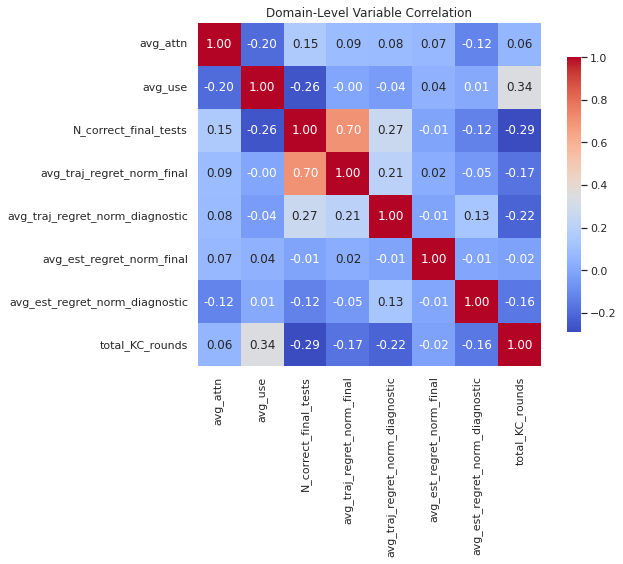

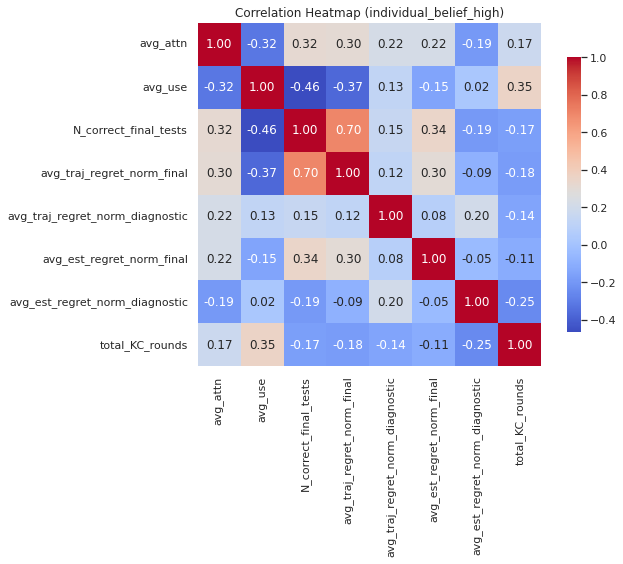

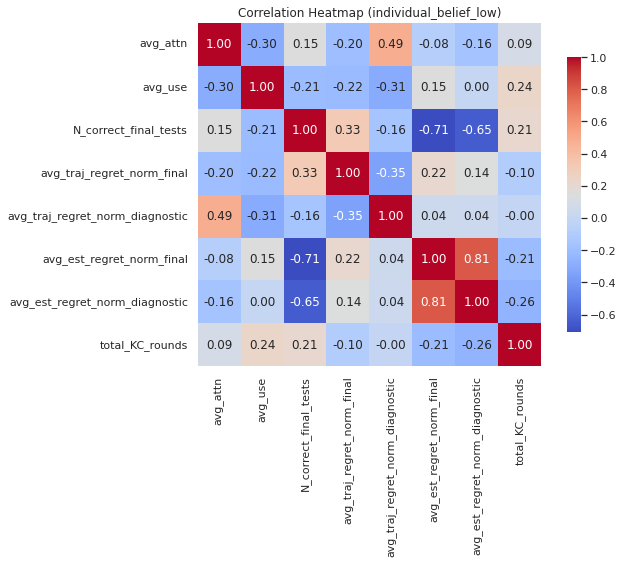

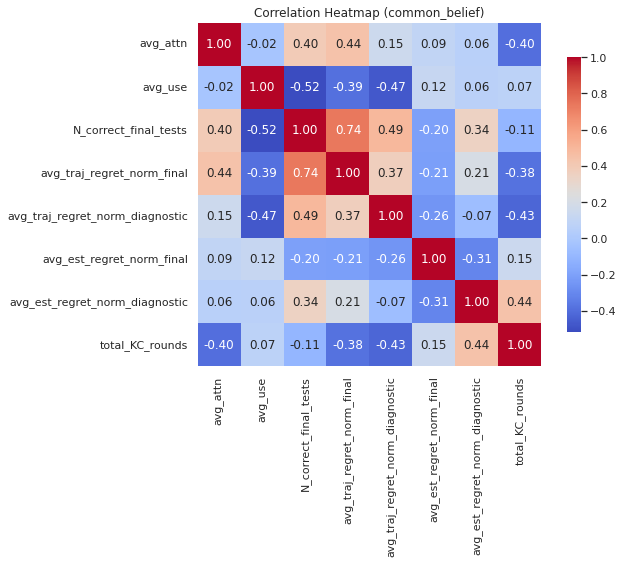

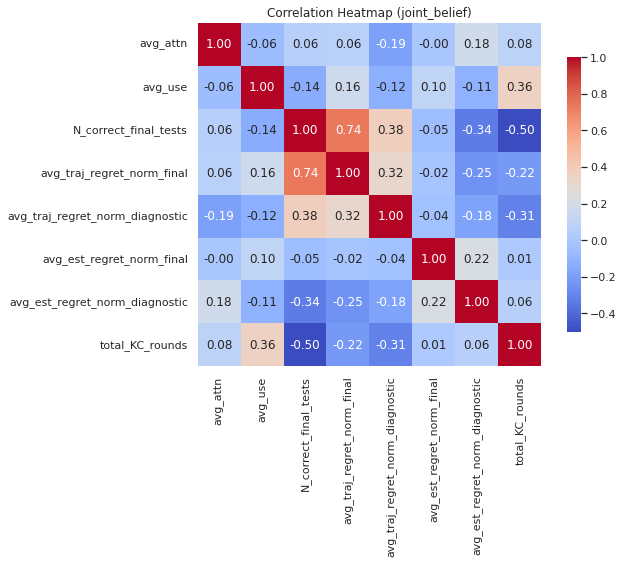

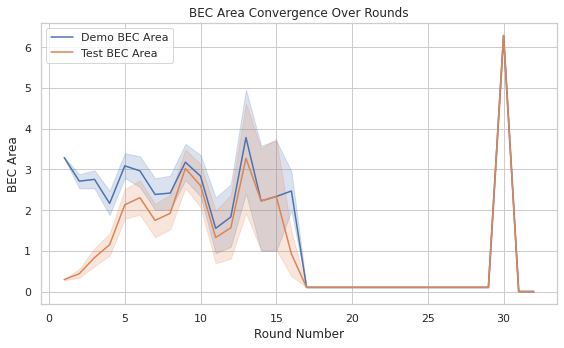

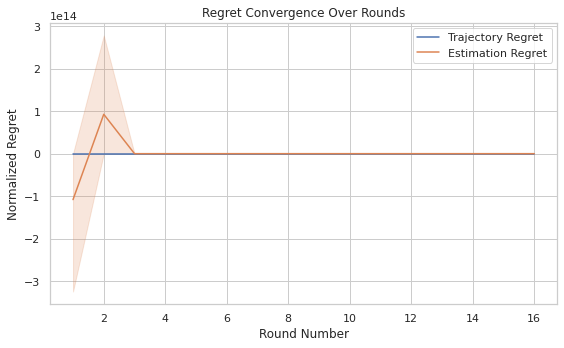

No 'KC' column found in round_df.


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Heat map between domain-level variables (correlation matrix)
def plot_correlation_heatmap(df, variables, title):
    corr = df[variables].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

# --- 2. Heat maps split by experimental condition
def plot_heatmap_by_condition(df, variables, condition_col='experimental_condition'):
    for cond in df[condition_col].unique():
        sub_df = df[df[condition_col] == cond]
        if len(sub_df) > 2:
            plot_correlation_heatmap(sub_df, variables, f"Correlation Heatmap ({cond})")

# --- 3. Trends in BEC convergence (test vs demo BEC area over rounds)
def plot_bec_convergence(round_df):
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=round_df, x='round_num', y='demo_BEC_area', label='Demo BEC Area')
    sns.lineplot(data=round_df, x='round_num', y='test_BEC_area', label='Test BEC Area')
    plt.title("BEC Area Convergence Over Rounds")
    plt.xlabel("Round Number")
    plt.ylabel("BEC Area")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- 4. Trends in regret convergence over rounds
def plot_regret_convergence(round_df):
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=round_df, x='round_num', y='avg_traj_regret_norm', label='Trajectory Regret')
    sns.lineplot(data=round_df, x='round_num', y='avg_est_regret_norm', label='Estimation Regret')
    plt.title("Regret Convergence Over Rounds")
    plt.xlabel("Round Number")
    plt.ylabel("Normalized Regret")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- 5. Regret convergence by Knowledge Component (KC)
def plot_regret_convergence_by_KC(round_df):
    if 'KC' not in round_df.columns:
        print("No 'KC' column found in round_df.")
        return
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=round_df, x='round_num', y='avg_traj_regret_norm', hue='KC')
    plt.title("Trajectory Regret Convergence by KC")
    plt.xlabel("Round Number")
    plt.ylabel("Normalized Trajectory Regret")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=round_df, x='round_num', y='avg_est_regret_norm', hue='KC')
    plt.title("Estimation Regret Convergence by KC")
    plt.xlabel("Round Number")
    plt.ylabel("Normalized Estimation Regret")
    plt.tight_layout()
    plt.show()

# Run plots
plot_correlation_heatmap(domain_df, domain_vars, "Domain-Level Variable Correlation")
plot_heatmap_by_condition(domain_df, domain_vars)
plot_bec_convergence(round_df)
plot_regret_convergence(round_df)

# Check if 'KC' column exists for KC-specific plot
plot_regret_convergence_by_KC(round_df)


     user_id group_id domain  round_num  N_correct_diagnostic_tests  \
0       62_2     20_2     sb          1                           1   
1       64_2     20_2     sb          1                           0   
2       65_2     20_2     sb          1                           0   
12      61_2     21_2     at          1                           0   
75     105_2     33_2     at          2                           0   
76     106_2     33_2     at          2                           2   
77     107_2     33_2     at          2                           0   
606    109_1     30_1     at          2                           0   
615    109_1     30_1     at          3                           0   
616    110_1     30_1     at          3                           1   
617    114_1     30_1     at          3                           1   
1024   157_1     45_1     sb          3                           2   

      proportion_correct_diagnostic_tests  lesson_learned  demo_BEC_area  \


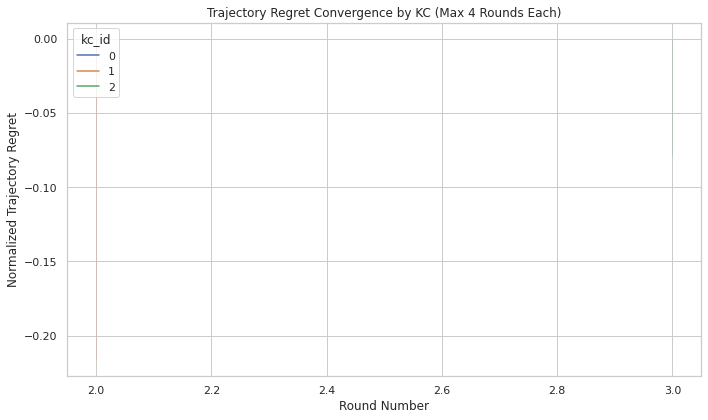

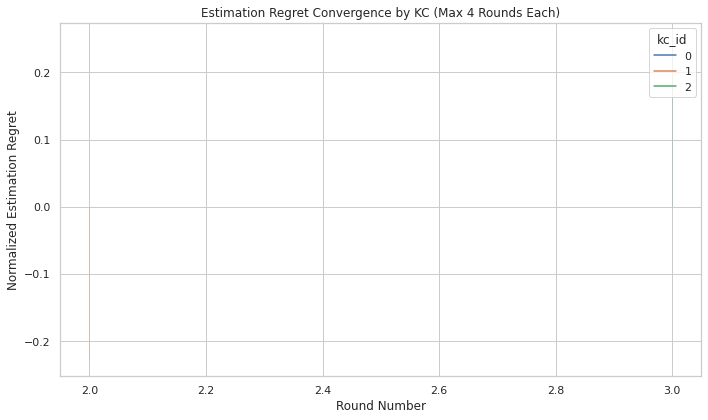

In [ ]:
if 'kc_id' in round_df.columns:
    round_df['kc_id'] = round_df['kc_id'].astype(str)

    # Sample up to 4 rounds per KC
    sampled_round_df = round_df.groupby('kc_id', group_keys=False).apply(lambda x: x.nsmallest(4, 'round_num'))

    print(sampled_round_df)

    # Trajectory regret plot by KC
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=sampled_round_df, x='round_num', y='avg_traj_regret_norm', hue='kc_id')
    plt.title("Trajectory Regret Convergence by KC (Max 4 Rounds Each)")
    plt.xlabel("Round Number")
    plt.ylabel("Normalized Trajectory Regret")
    plt.tight_layout()
    plt.show()

    # Estimation regret plot by KC
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=sampled_round_df, x='round_num', y='avg_est_regret_norm', hue='kc_id')
    plt.title("Estimation Regret Convergence by KC (Max 4 Rounds Each)")
    plt.xlabel("Round Number")
    plt.ylabel("Normalized Estimation Regret")
    plt.tight_layout()
    plt.show()
else:
    print("No 'kc_id' column found in round_df.")
